In [3]:
# Environment Setup & Data Loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Load data
df = pd.read_csv(r'UIH EDA/Mumbai Daily Temperature Data 1951 to 2024.csv')
df.columns = df.columns.str.strip()

# Clean numeric columns
df['Temp Max'] = pd.to_numeric(df['Temp Max'], errors='coerce')
df['Temp Min'] = pd.to_numeric(df['Temp Min'], errors='coerce')
df['Rain']     = pd.to_numeric(df['Rain'], errors='coerce')

df.drop(columns=['_id'], inplace=True)
print(df.head(5))

         Date  Rain   Temp Max  Temp Min
0  01-01-1951   NaN  28.530001     14.54
1  02-01-1951   NaN  28.850000     14.48
2  03-01-1951   NaN  30.660000     14.43
3  04-01-1951   NaN  30.139999     14.36
4  05-01-1951   NaN  29.180000     13.34


In [13]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce', dayfirst=True)
df = df.dropna(subset=['Date'])
df.set_index('Date', inplace=True)
print(type(df.index))

<class 'pandas.core.indexes.datetimes.DatetimeIndex'>


In [14]:
print(f"Total years: {df.index.year.nunique()}")

Total years: 74


In [15]:
# Dataset Overview & Shape
print(f"Shape: {df.shape}")
print(f"Date range: {df.index.min()} → {df.index.max()}")
print(f"Total years: {df.index.year.nunique()}")
print()
print(df.info())
print()
print(df.describe().round(2))

Shape: (26803, 3)
Date range: 1951-01-01 00:00:00 → 2024-06-19 00:00:00
Total years: 74

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26803 entries, 1951-01-01 to 2024-06-19
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Rain      1143 non-null   float64
 1   Temp Max  26746 non-null  float64
 2   Temp Min  26744 non-null  float64
dtypes: float64(3)
memory usage: 837.6 KB
None

          Rain  Temp Max  Temp Min
count  1143.00  26746.00  26744.00
mean      9.06     32.08     20.76
std      38.92      2.72      3.82
min       0.00     22.72      7.21
25%       0.00     29.97     17.60
50%       0.00     31.86     22.14
75%       2.00     34.20     23.68
max    1011.70     40.90     30.00


In [17]:
# Missing Value Analysis
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
print(pd.DataFrame({'Missing': missing, '%': missing_pct}))

df['Temp Min'].fillna(df['Temp Min'].median(), inplace=True)
df_rain = df.dropna(subset=['Rain'])  # 1238 rainy-season rows
print(f"Rain rows available: {len(df_rain)}")

          Missing      %
Rain        25660  95.74
Temp Max       57   0.21
Temp Min       59   0.22
Rain rows available: 1143


In [16]:
# Finding Temperature Mean
df['Temp Max'] = pd.to_numeric(df['Temp Max'], errors='coerce')
df['Temp Min'] = pd.to_numeric(df['Temp Min'], errors='coerce')

# Create mean temperature
df['temp_mean'] = (df['Temp Max'] + df['Temp Min']) / 2

Temp Max: 3 IQR outliers | fence [23.6, 40.5]
Temp Min: 5 IQR outliers | fence [8.5, 32.8]


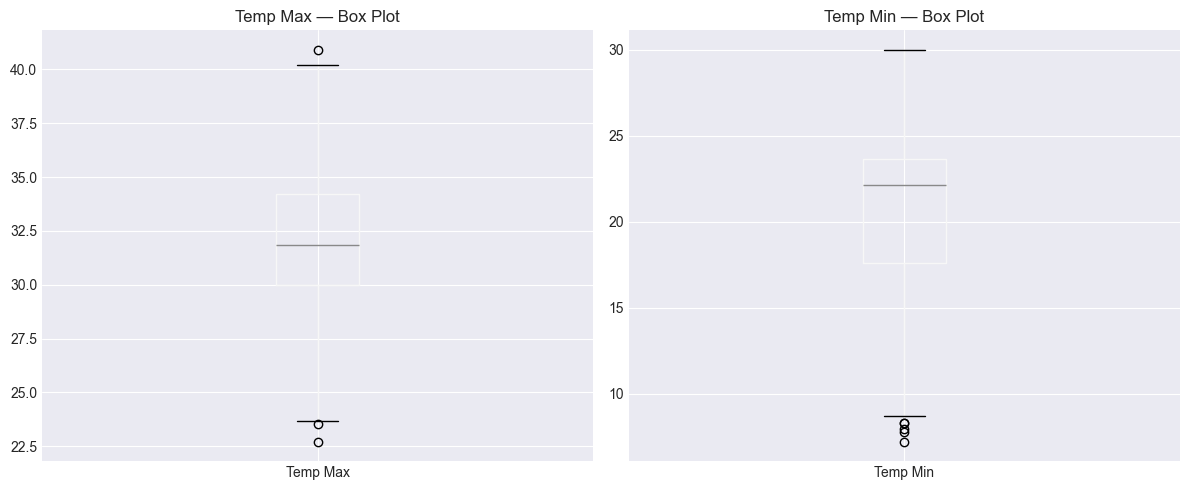

In [18]:
# Outlier Detection
from scipy import stats

for col in ['Temp Max', 'Temp Min']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} IQR outliers | fence [{lower:.1f}, {upper:.1f}]")

# Box plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col in zip(axes, ['Temp Max', 'Temp Min']):
    df.boxplot(column=col, ax=ax)
    ax.set_title(f'{col} — Box Plot')
plt.tight_layout(); plt.show()

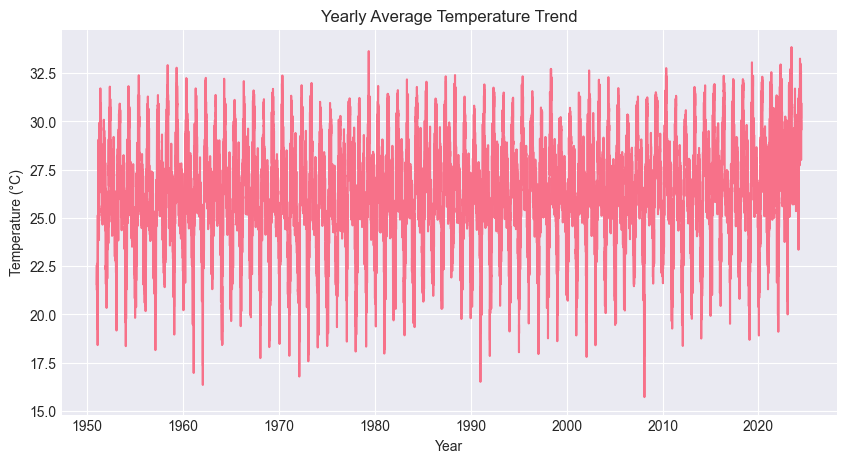

In [29]:
# Yearly Average Temperature Trend
yearly = df.groupby('Date')['temp_mean'].mean()
plt.figure(figsize=(10,5))
plt.plot(yearly)
plt.title("Yearly Average Temperature Trend")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.show()

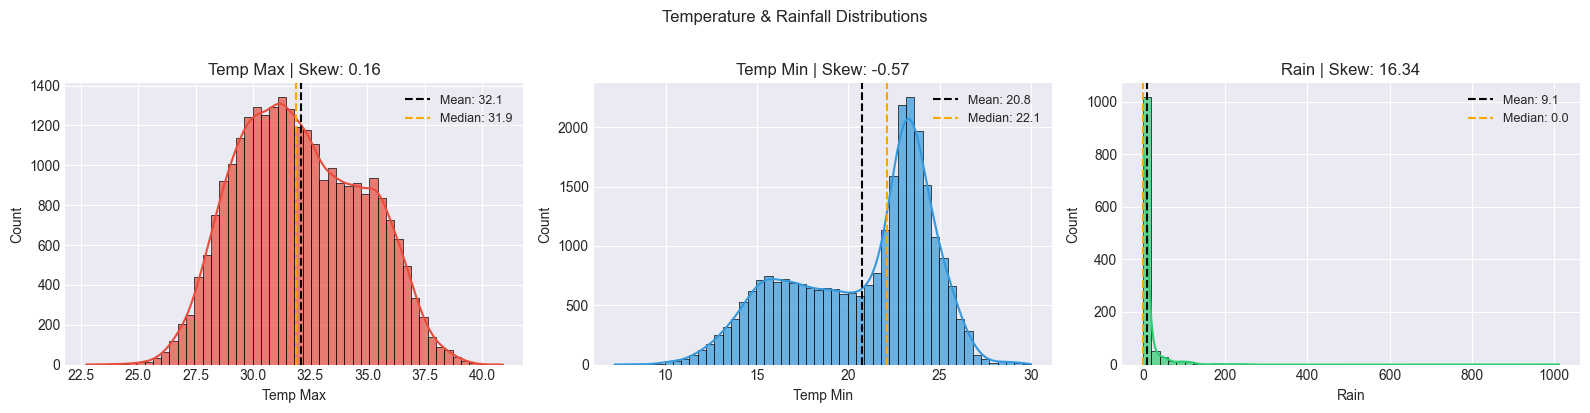

In [19]:
# Seasonal & Monthly Patterns
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col, color in zip(axes,
        ['Temp Max', 'Temp Min', 'Rain'],
        ['#e74c3c', '#3498db', '#2ecc71']):
    data = df[col].dropna()
    sns.histplot(data, kde=True, ax=ax,
                 color=color, bins=50, alpha=0.7)
    ax.axvline(data.mean(), color='k', ls='--',
               label=f"Mean: {data.mean():.1f}")
    ax.axvline(data.median(), color='orange', ls='--',
               label=f"Median: {data.median():.1f}")
    ax.set_title(f'{col} | Skew: {data.skew():.2f}')
    ax.legend(fontsize=9)

plt.suptitle('Temperature & Rainfall Distributions', y=1.02)
plt.tight_layout(); plt.show()

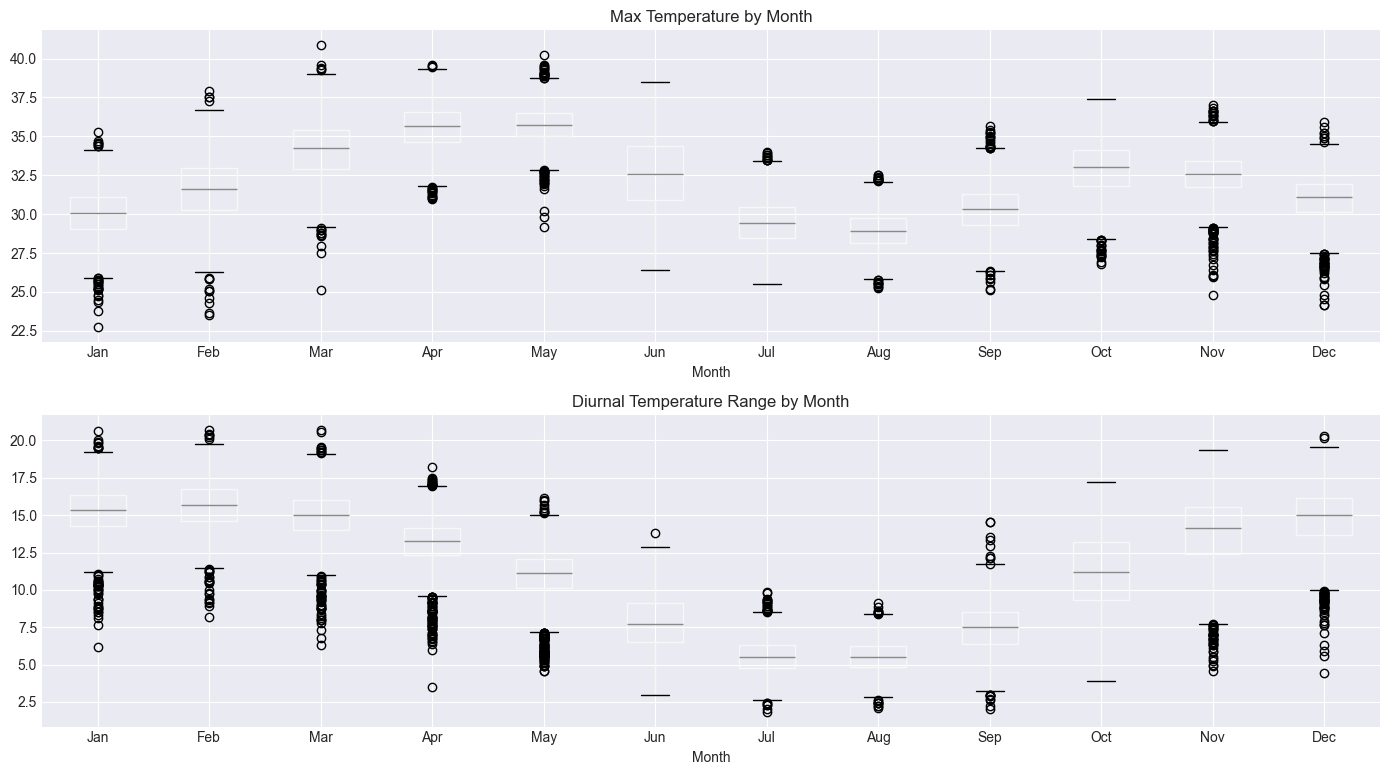

In [20]:
# Long-Term Trend Analysis
df['Month'] = df.index.month
df['Year']  = df.index.year
df['Diurnal Range'] = df['Temp Max'] - df['Temp Min']
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

# Monthly box plots
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

df.boxplot(column='Temp Max', by='Month', ax=axes[0])
axes[0].set_xticklabels(month_names)
axes[0].set_title('Max Temperature by Month')

df.boxplot(column='Diurnal Range', by='Month', ax=axes[1])
axes[1].set_xticklabels(month_names)
axes[1].set_title('Diurnal Temperature Range by Month')

plt.suptitle(''); plt.tight_layout(); plt.show()

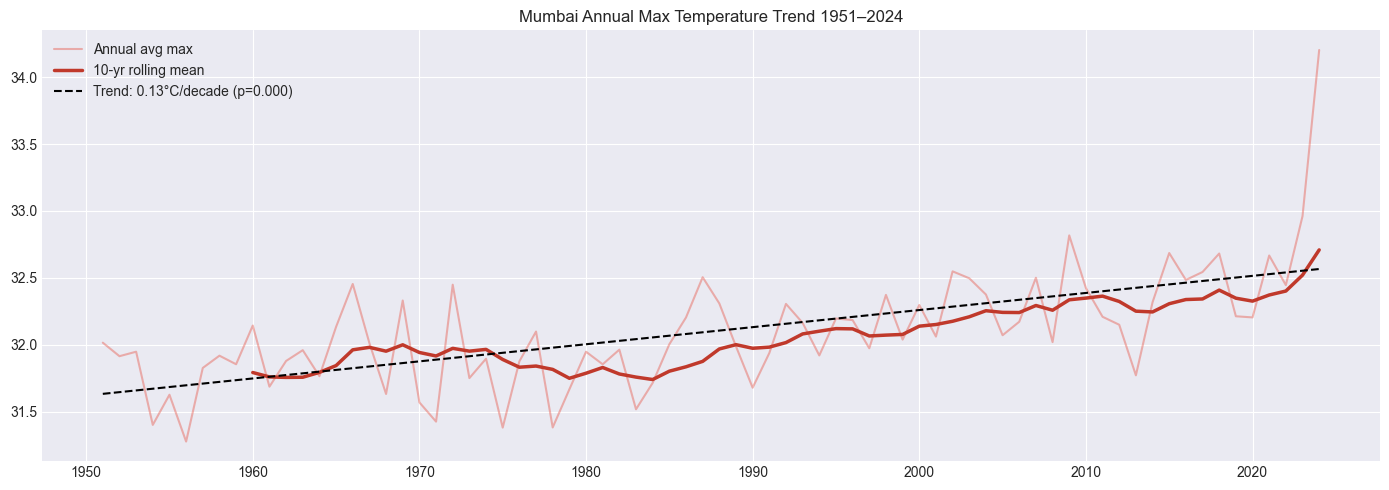

In [21]:
# Mumbai Annual Max Temperature Trend 1951–2024
annual = df.groupby('Year')[['Temp Max', 'Temp Min']].mean()
annual['rolling_max'] = annual['Temp Max'].rolling(10).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(annual.index, annual['Temp Max'],
       alpha=0.4, color='#e74c3c', label='Annual avg max')
ax.plot(annual.index, annual['rolling_max'],
       color='#c0392b', lw=2.5, label='10-yr rolling mean')

# Linear regression trend line
x = annual.index.values
slope, intercept, r, p, se = stats.linregress(x, annual['Temp Max'])
ax.plot(x, slope*x+intercept, 'k--', lw=1.5,
       label=f"Trend: {slope*10:.2f}°C/decade (p={p:.3f})")

ax.set_title('Mumbai Annual Max Temperature Trend 1951–2024')
ax.legend(); plt.tight_layout(); plt.show()

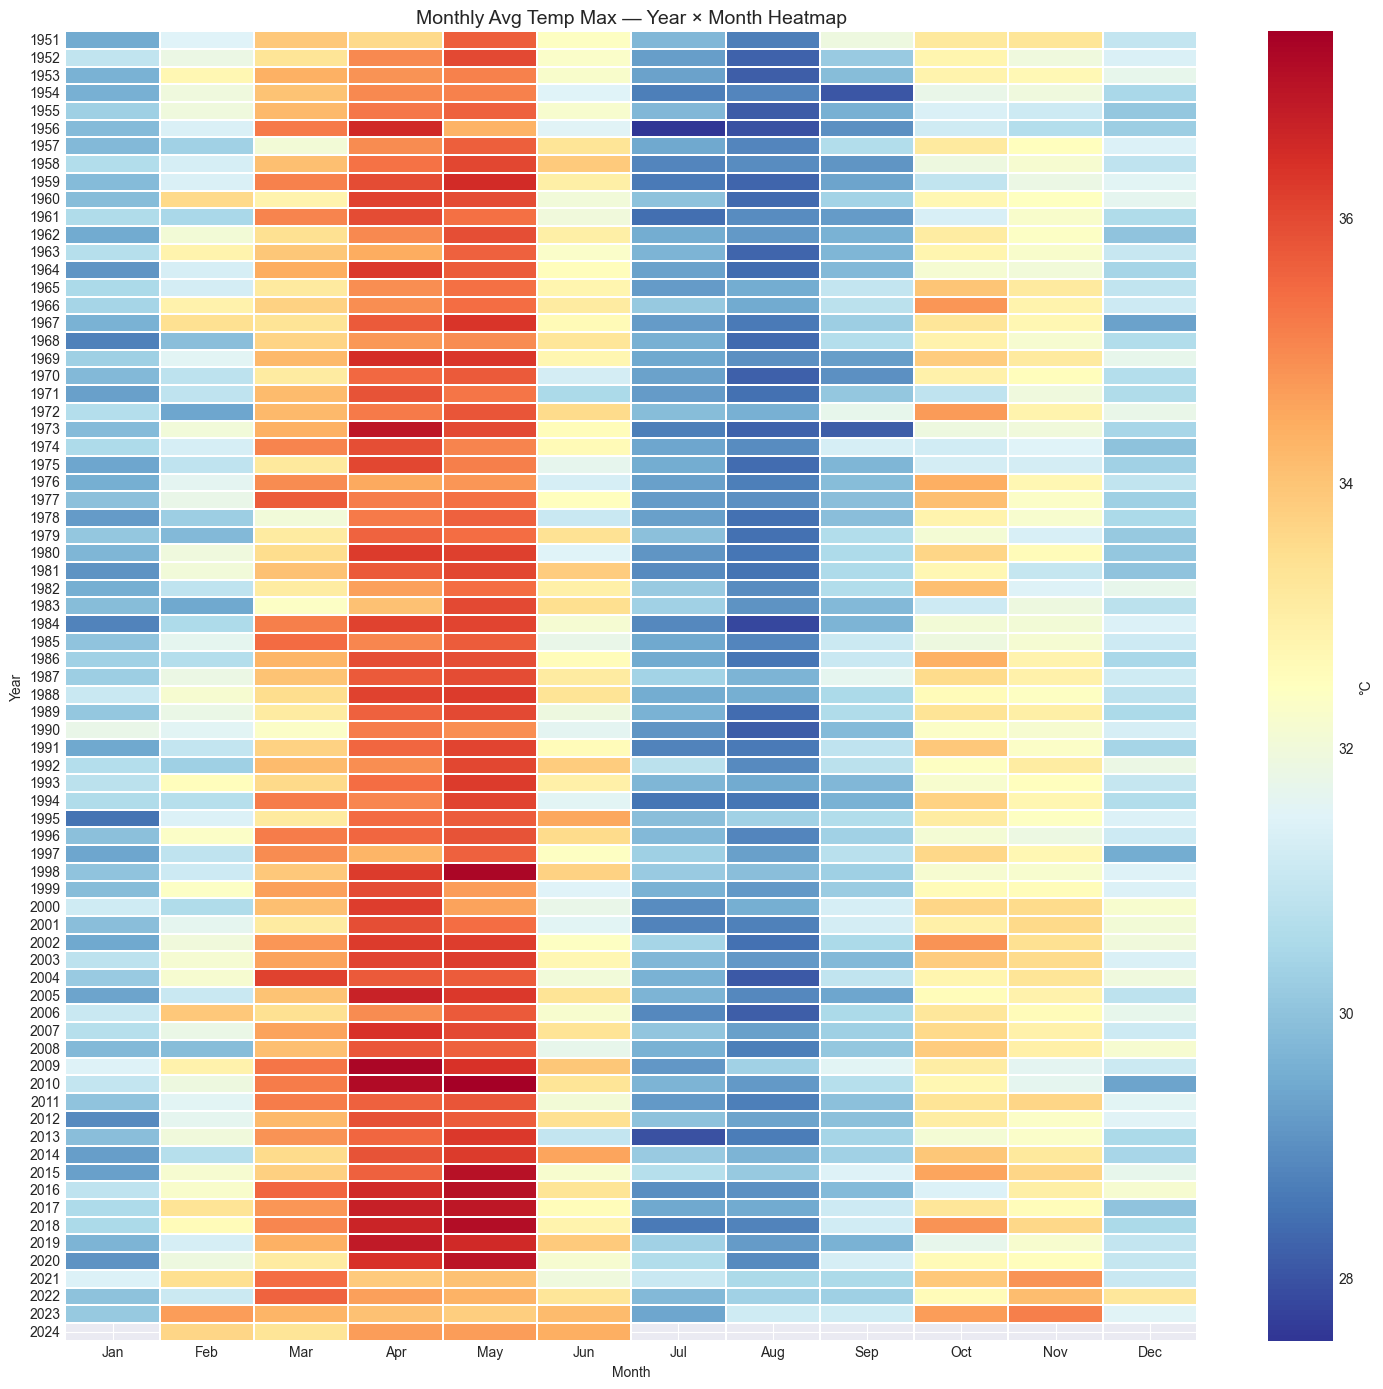

In [22]:
# Year × Month Heatmap
pivot = df.groupby(['Year', 'Month'])['Temp Max'].mean().\
           unstack('Month')
pivot.columns = month_names

fig, ax = plt.subplots(figsize=(15, 14))
sns.heatmap(pivot, cmap='RdYlBu_r', ax=ax,
            linewidths=0.3, annot=False,
            cbar_kws={'label':'°C'})
ax.set_title('Monthly Avg Temp Max — Year × Month Heatmap',
            fontsize=14)
ax.set_ylabel('Year'); ax.set_xlabel('Month')
plt.tight_layout(); plt.show()

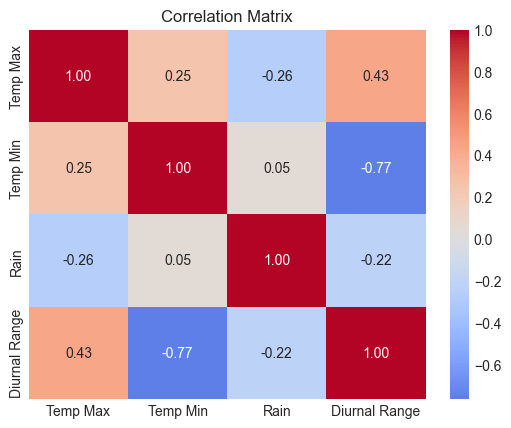

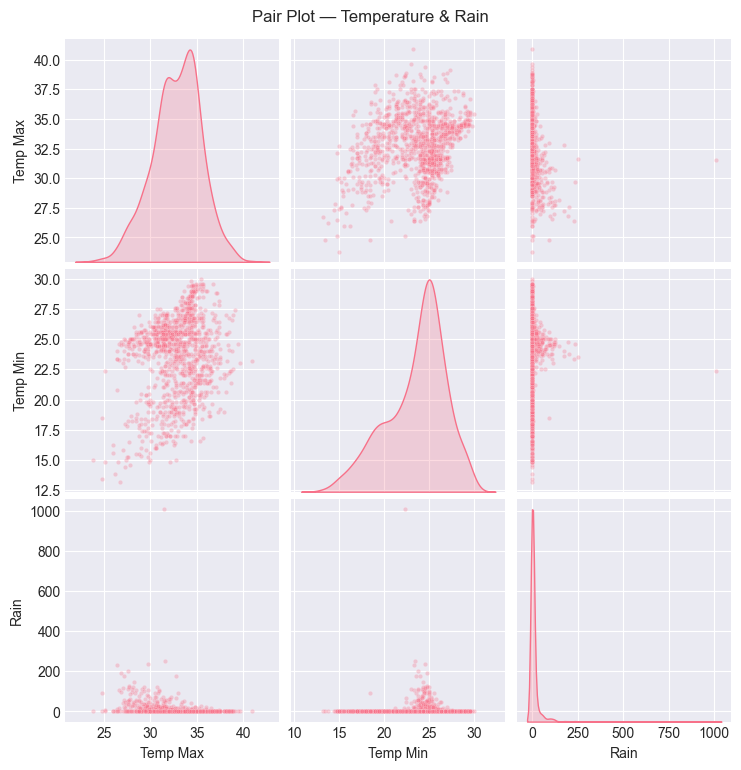

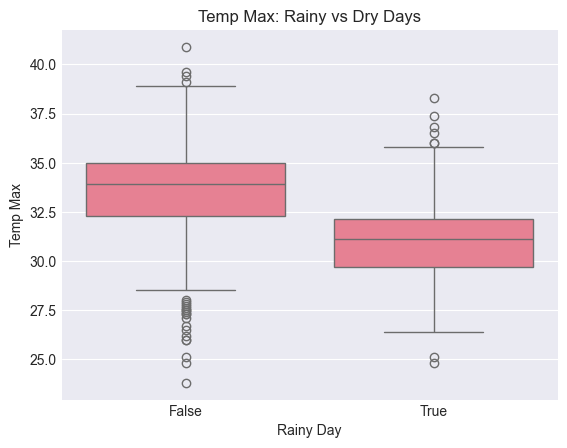

In [23]:
# Correlation & Bivariate Analysis
corr = df[['Temp Max', 'Temp Min', 'Rain', 'Diurnal Range']].corr()
sns.heatmap(corr, annot=True, fmt='.2f',
            cmap='coolwarm', center=0)
plt.title('Correlation Matrix'); plt.show()

# Pair plot (scatter matrix)
sns.pairplot(
    df[['Temp Max', 'Temp Min', 'Rain']].dropna(),
    diag_kind='kde', plot_kws={'alpha':0.3, 's':10}
)
plt.suptitle('Pair Plot — Temperature & Rain', y=1.02)
plt.show()

# Rainy vs dry day temperature comparison
df['Rainy Day'] = df['Rain'] > 0
sns.boxplot(x='Rainy Day', y='Temp Max', data=df.dropna())
plt.title('Temp Max: Rainy vs Dry Days'); plt.show()

Top 10 Hottest Days:
             Temp Max   Temp Min
Date                            
2021-03-28  40.900000  23.200000
1979-05-12  40.200001  27.080000
2022-03-15  39.600000  23.000000
1960-05-11  39.599998  24.740000
1955-04-21  39.580002  23.100000
2010-05-10  39.520000  25.260000
2019-04-27  39.491016  26.626352
1960-05-09  39.480000  23.309999
2017-04-13  39.454353  22.427052
2023-03-13  39.400000  24.600000


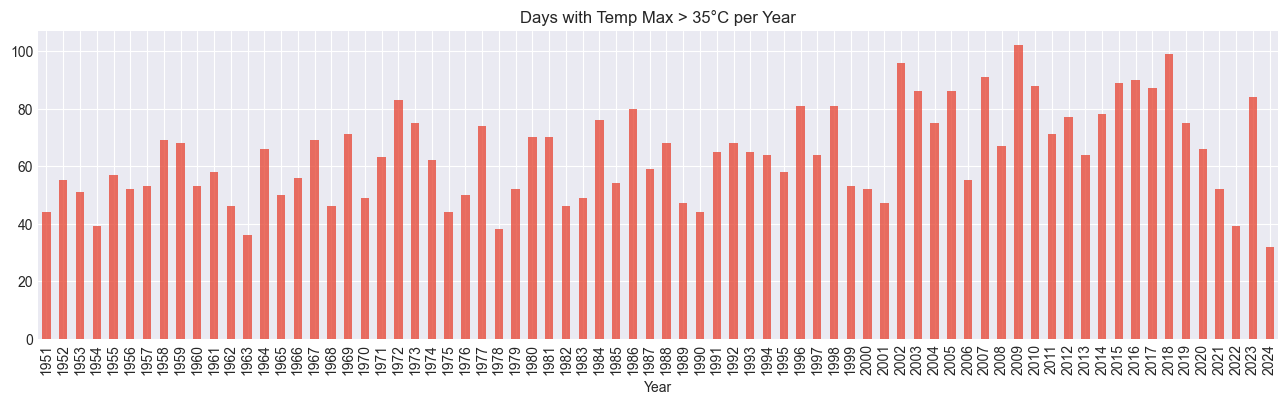

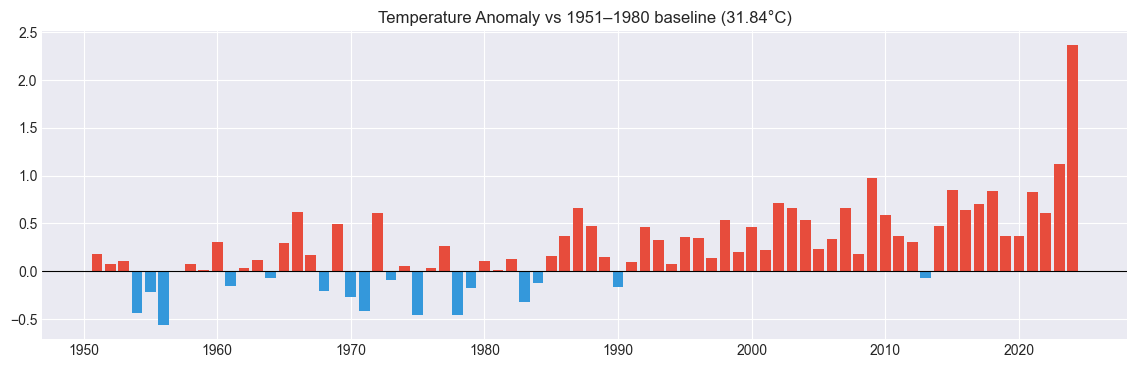

In [24]:
# Extreme Events & Temperature Anomaly
print("Top 10 Hottest Days:")
print(df.nlargest(10, 'Temp Max')[['Temp Max', 'Temp Min']])

# Heatwave days (>35°C) per year
hw = df[df['Temp Max'] > 35].groupby('Year').size()
hw.plot(kind='bar', figsize=(16, 4),
        color='#e74c3c', alpha=0.8)
plt.title('Days with Temp Max > 35°C per Year')
plt.show()

# Temperature anomaly chart
baseline = df[df['Year'] <= 1980]['Temp Max'].mean()
anomaly  = annual['Temp Max'] - baseline
colors   = ['#e74c3c' if v > 0 else '#3498db' for v in anomaly]
plt.figure(figsize=(14, 4))
plt.bar(anomaly.index, anomaly.values, color=colors)
plt.axhline(0, color='k', lw=0.8)
plt.title(f'Temperature Anomaly vs 1951–1980 baseline ({baseline:.2f}°C)')
plt.show()